In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))  # adiciona a pasta acima (raiz do projeto) no path

# Modelo Base - Classificação Multiclasse
Treinamento de uma CNN simples com CIFAR-10.

# Imports e Dataset

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from models.modelo_base import ModeloBase
from utils.train import train
from utils.test import test
from utils.metrics import plot_confusion_matrix, plot_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data/dataset_usado', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data/dataset_usado', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes

100.0%


# Treinamento

In [4]:
model = ModeloBase(num_classes=10).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

for epoch in range(5):
    train_loss, train_acc = train(model, trainloader, criterion, optimizer, device)
    test_loss, test_acc = test(model, testloader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

Epoch 1: Train Acc=0.4887, Test Acc=0.5775
Epoch 2: Train Acc=0.6122, Test Acc=0.6267
Epoch 3: Train Acc=0.6647, Test Acc=0.6564
Epoch 4: Train Acc=0.7004, Test Acc=0.6798
Epoch 5: Train Acc=0.7311, Test Acc=0.6826


# Matriz de Confusão

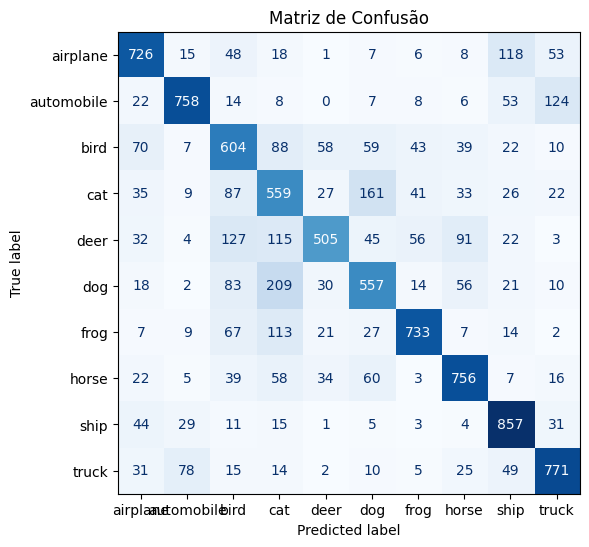

In [5]:
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

plot_confusion_matrix(y_true, y_pred, classes)

# Gráficos

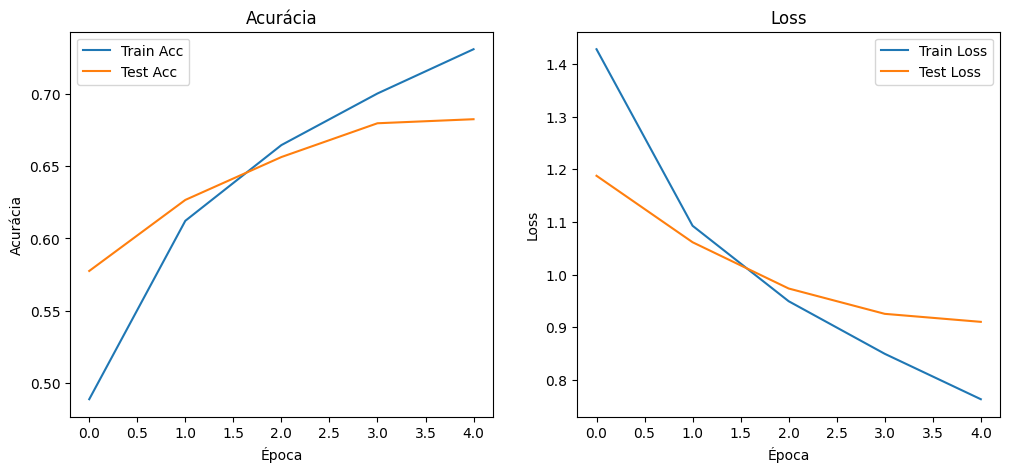

In [6]:
plot_metrics(train_accuracies, test_accuracies, train_losses, test_losses)